In [1]:
from src.bench_dataset import DronePairDataset

FOLDER_A_TEST = 'data/v5/SCD_images/test'
FOLDER_B_TEST = 'data/v5/YOLO/stationary/test'
dataset = DronePairDataset(FOLDER_A_TEST, FOLDER_B_TEST)


--- Dataset Statistics ---
Total Pairs: 1651

Range Wise (Distance):
  0.0m: 127 images
  1.0m: 381 images
  2.0m: 381 images
  3.0m: 381 images
  4.0m: 381 images

Class Wise (ID):
  Class -1 (Background): 127 images
  Class 0 (Phantom): 508 images
  Class 1 (Matrice): 508 images
  Class 2 (Mavic): 508 images


In [2]:
len(dataset)

1651

In [3]:
import random
random_idx = random.randint(0, len(dataset) - 1)
dataset[random_idx]

('data/v5/SCD_images/test/scd_NO_DRONE_99_0.00m.png',
 'data/v5/YOLO/stationary/test/images/phantom_0m_4.png',
 -1,
 0.0,
 0)

Total uncertain pairs: 508


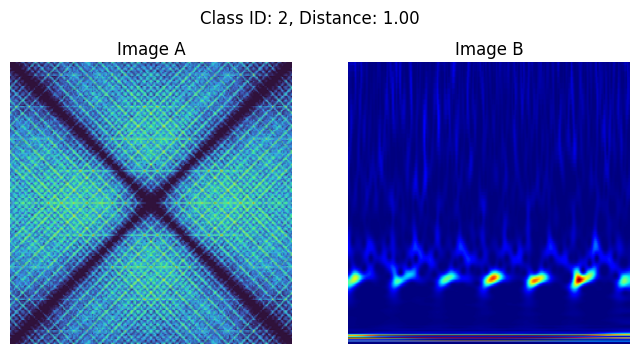

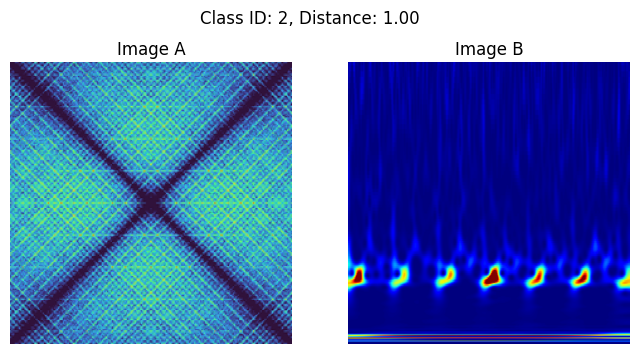

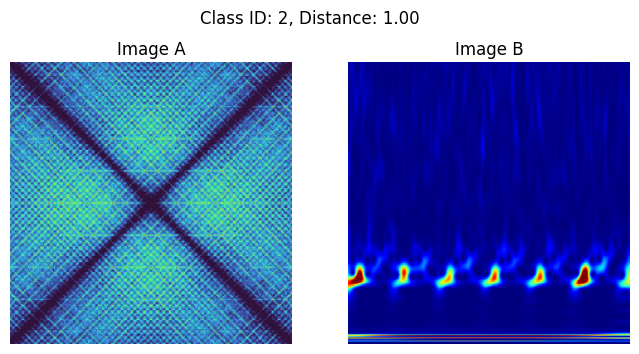

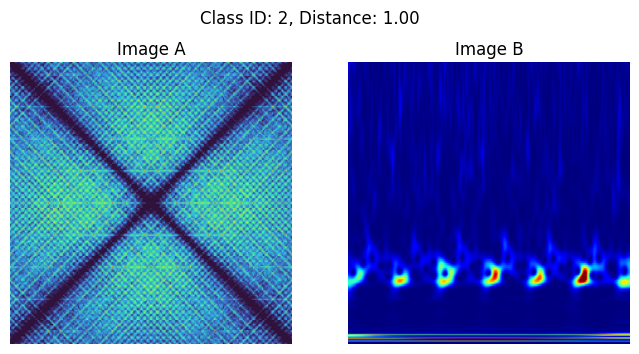

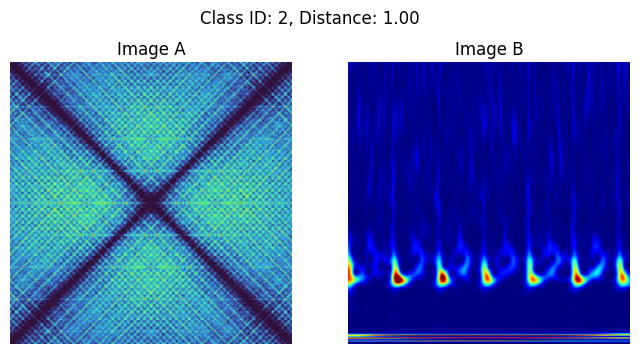

In [6]:
# plot images some images with uncerain (4) as the label
import matplotlib.pyplot as plt
def plot_image_pair(dataset, idx):
    pair = dataset[idx]
    img_a_path = pair[0]
    img_b_path = pair[1]
    class_id = pair[2]
    dist = pair[3]

    img_a = plt.imread(img_a_path)
    img_b = plt.imread(img_b_path)

    plt.figure(figsize=(8, 4))
    plt.suptitle(f"Class ID: {class_id}, Distance: {dist:.2f}")
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_a)
    plt.title("Image A")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img_b)
    plt.title("Image B")
    plt.axis('off')
    
    plt.show()

# get few images with class_id 4 (uncertain)
uncertain_indices = [i for i, p in enumerate(dataset.pairs) if p['class_id'] == 2]
print(f"Total uncertain pairs: {len(uncertain_indices)}")
for idx in uncertain_indices[:5]:  # plot first 5 uncertain pairs
    plot_image_pair(dataset, idx)